# Week 3 Demo 3A: Clustering with the Iris Dataset

This notebook demonstrates **unsupervised learning** using the clean Iris dataset.

In this notebook, we will:

1. Load the clean Iris dataset.
2. Select numerical columns to use as input features.
3. Apply **k-means clustering**.
4. Visualize the clusters.
5. Compare the clusters with the true Iris species labels for learning purposes.

**Important:** The true species labels are **not used** to create the clusters. We only use them at the end to understand how well the clusters match known species.

## Step 1: Import the tools we need

These libraries help us load the dataset, organize it in a table, run clustering, and create plots.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 2. Read/Import the data

You have two options to import/get the file into the notebook

1. Upload `iris.csv` from your desktop
2. Get it from a URL directly to the notebook

Click the run button ▶️ on the left side for eaither option 1 or 2 to run the cell.

Once you complete the step you should be able to see the first few rows of the dataset.

In [ ]:
# Option (1)
from google.colab import files
import pandas as pd
uploaded = files.upload()
iris_df = pd.read_csv("iris.csv")
iris_df.head()

In [2]:
# Option (2) No need to execute this if option (1) worked
import pandas as pd
url = "https://raw.githubusercontent.com/UConnARIAL/NRE5615_EnviroAI_Code_and_Data/main/data/iris.csv"
iris_df = pd.read_csv(url)
iris_df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,iris_species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: View the available columns



## Step 4: Select the input columns for clustering

For clustering, we select numerical columns only. This is similar to using the **Select Columns** widget in Orange.

Try changing `selected_columns` later to see how the cluster plot changes.

In [6]:
selected_columns = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm"
]

X = iris_df[selected_columns].copy()

print("Selected input columns:")
print(selected_columns)

X.head()

Selected input columns:
['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Step 5: Run k-means clustering

K-means is an unsupervised learning method. It tries to group rows that are similar to each other.

We will ask for **3 clusters** because the Iris dataset contains three known species. However, the clustering algorithm does not know the species names.

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
iris_df["cluster"] = kmeans.fit_predict(X)

iris_df[["iris_species", "cluster"]].head(10)

,iris_species,cluster
0,setosa,1
1,setosa,1
2,setosa,1
3,setosa,1
4,setosa,1
5,setosa,1
6,setosa,1
7,setosa,1
8,setosa,1
9,setosa,1


## Step 6: Visualize the clusters using two selected columns

A scatter plot helps us see whether the clusters are separated or overlapping.

Here we use **petal length** and **petal width** because they are often useful for separating Iris flowers.

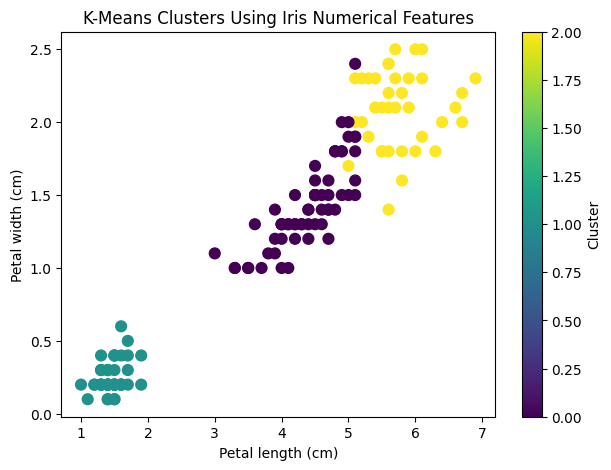

In [11]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    iris_df["petal_length_cm"],
    iris_df["petal_width_cm"],
    c=iris_df["cluster"],
    s=60
)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("K-Means Clusters Using Iris Numerical Features")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Step 7: Visualize the clusters using PCA

PCA is a method that helps us display several input columns in a two-dimensional plot.

This is useful when we use more than two input variables.

In Orange, a similar visualization can be created using the **PCA** widget followed by a **Scatter Plot**.

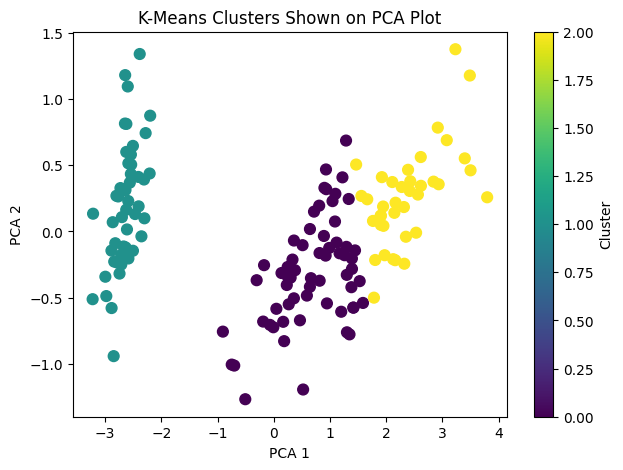

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

iris_df["PCA 1"] = X_pca[:, 0]
iris_df["PCA 2"] = X_pca[:, 1]

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    iris_df["PCA 1"],
    iris_df["PCA 2"],
    c=iris_df["cluster"],
    s=60
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Shown on PCA Plot")
plt.colorbar(scatter, label="Cluster")
plt.show()

## Step 8: Compare clusters with the true species labels

This comparison is only for interpretation. The species labels were **not** used to build the clusters.

A table like this can help us see whether clusters match the known species.

In [13]:
comparison_table = pd.crosstab(iris_df["iris_species"], iris_df["cluster"])
comparison_table

cluster,0,1,2
iris_species,,,
setosa,0,50,0
versicolor,48,0,2
virginica,14,0,36


## Step 9: Reflection questions

Try to answer these questions.

1. Do the clusters appear clearly separated or overlapping?
2. Which variables seem helpful for separating the clusters?
3. When compared with the true species labels, do the clusters match well, partly, or poorly?
4. Why might clustering not perfectly match the real species labels?

## Optional: Try selecting fewer columns

You can rerun the notebook after changing `selected_columns`. For example, try using only:

```python
selected_columns = ["petal length (cm)", "petal width (cm)"]
```

Then rerun the clustering and plots. This helps you see how column selection affects the results.

## Orange demonstration reminder

To demonstrate the same idea in Orange:

1. Load the Iris dataset.
2. Use **Select Columns** to choose numerical features.
3. Send the selected data to **k-Means**.
4. Use **Scatter Plot** or **PCA** to view the clusters.
5. Optionally compare clusters with the species label after clustering.

The key idea is the same: clustering uses input features to find groups without using the class label.